In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋'
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model,load_model
from tensorflow.keras.layers import Dense,Input,Dropout,BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU,ELU,LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [4]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',',skiprows=1)
data.shape

(100, 785)

In [17]:
print('타겟변수:',data[0,0])
image = data[7,1:].reshape(28,28)
image.shape

타겟변수: 5.0


(28, 28)

In [18]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}",end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 38 43105255253253253253253174  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 43139224226252253252252252252252252158 14  0  0  0  0  0
  0  0  0  0  0  0  0  0  0178252252252252253252252252252252252252 59  0  0  0  0  0
  0  0  0  0  0  0  0  0  0109252252230132133132132189252252252252 59  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  4 29 29 24  0  0  0  0 14226252252172  7  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 85243252252144  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 88189252252252 1

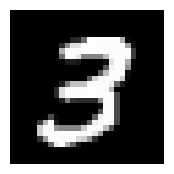

In [21]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image,cmap='gray')
plt.axis('off')
plt.show()

In [27]:
# 칼라사진 -> 흑백모드로 넘파이 배열로 읽기 (pip install opencv-python==4.8.178)
import cv2
image_array = cv2.imread('data/sample.jpg')
image_array.shape, type(image_array)

((408, 612, 3), numpy.ndarray)

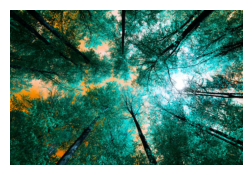

In [28]:
plt.gigure(figsize=(3,4))
plt.imshow(image_array,cmap='gray')
plt.axis()


# 1. 데이터 생성및 전처리

In [29]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

11490434/11490434 [==============================] - 1s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [30]:
value,counts = np.unique(y_train,return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value,ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [31]:
value,counts = np.unique(y_test,return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value,ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0

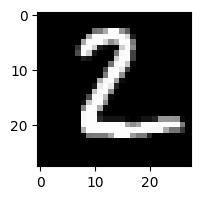

In [35]:
print(y_test[1])
plt.imshow(X_test[1],cmap='gray')
plt.show
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}",end='')
    print()

In [3]:
# Train데이터에 6만개 => Train(5만개)+val(만개)로 분리
(X_train, y_train), (X_test, y_test) = mnist.load_data() # 6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [4]:
print('학습셋:',X_train.shape,y_train.shape)
print('검증셋:',X_val.shape, y_val.shape)
print('시험셋:',X_test.shape,y_test.shape)

학습셋: (50000, 28, 28) (50000,)
검증셋: (10000, 28, 28) (10000,)
시험셋: (10000, 28, 28) (10000,)


In [5]:
# 입력(독립) 변수(n,28,28) ->(n,28*28) -> 실수로 형변환 ->스케일 조정(/255.0)
train_X = X_train.reshape(50000,28*28).astype('float32')/255.0
val_X = X_val.reshape(10000,784).astype('float32')/255.0
test_X = X_val.reshape(10000,-1).astype('float32')/255.0
train_X.shape,val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [6]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train,10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_Y.shape,val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [7]:
# Train 5만 ->임의로 700개,val 1만 -> 임의로 300개 추출해서 학습
#idx=random.sample(range(50000),700)
train_idx=np.random.choice(50000,700) # 0~50000미만의 700개의 수 비복원추출
val_idx  = np.random.choice(10000,300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X = val_X[val_idx]
val_Y = val_Y[val_idx]

In [8]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델구성
# 3. 학습과정 설정


In [9]:
model = Sequential(name='sequential')
model.add(Input(shape=784,))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01))# 음수결과에 대해 1%만 통과
model.add(Dense(units=10,activation='softmax'))
model.summary()
# 타겟변수를 원핫 인코딩 안했다면  sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
              optimizer = 'adam',
              metrics=['accuracy'])# 평가지표

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 2)                 0         
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델학습

In [10]:
%%time
hist = model.fit(train_X,train_Y,#학습셋
                validation_data=(val_X,val_Y),#검증셋
                batch_size=100,
                epochs=200
                )

Epoch 1/200
7/7 [==============================] - 1s 60ms/step - loss: 2.2913 - accuracy: 0.1514 - val_loss: 2.2924 - val_accuracy: 0.1367
Epoch 2/200
7/7 [==============================] - 0s 11ms/step - loss: 2.2676 - accuracy: 0.1686 - val_loss: 2.2761 - val_accuracy: 0.1433
Epoch 3/200
7/7 [==============================] - 0s 7ms/step - loss: 2.2450 - accuracy: 0.1757 - val_loss: 2.2585 - val_accuracy: 0.1567
Epoch 4/200
7/7 [==============================] - 0s 10ms/step - loss: 2.2257 - accuracy: 0.1843 - val_loss: 2.2424 - val_accuracy: 0.1733
Epoch 5/200
7/7 [==============================] - 0s 10ms/step - loss: 2.2043 - accuracy: 0.1929 - val_loss: 2.2285 - val_accuracy: 0.1633
Epoch 6/200
7/7 [==============================] - 0s 9ms/step - loss: 2.1844 - accuracy: 0.1871 - val_loss: 2.2158 - val_accuracy: 0.1600
Epoch 7/200
7/7 [==============================] - 0s 9ms/step - loss: 2.1658 - accuracy: 0.1857 - val_loss: 2.1993 - val_accuracy: 0.1533
Epoch 8/200
7/7 [======

7/7 [==============================] - 0s 9ms/step - loss: 1.5859 - accuracy: 0.3943 - val_loss: 1.6876 - val_accuracy: 0.3433
Epoch 60/200
7/7 [==============================] - 0s 8ms/step - loss: 1.5785 - accuracy: 0.4243 - val_loss: 1.6819 - val_accuracy: 0.3500
Epoch 61/200
7/7 [==============================] - 0s 9ms/step - loss: 1.5711 - accuracy: 0.4300 - val_loss: 1.6746 - val_accuracy: 0.3533
Epoch 62/200
7/7 [==============================] - 0s 13ms/step - loss: 1.5638 - accuracy: 0.4271 - val_loss: 1.6683 - val_accuracy: 0.3600
Epoch 63/200
7/7 [==============================] - 0s 9ms/step - loss: 1.5569 - accuracy: 0.4300 - val_loss: 1.6612 - val_accuracy: 0.3667
Epoch 64/200
7/7 [==============================] - 0s 10ms/step - loss: 1.5503 - accuracy: 0.4329 - val_loss: 1.6558 - val_accuracy: 0.3700
Epoch 65/200
7/7 [==============================] - 0s 11ms/step - loss: 1.5434 - accuracy: 0.4343 - val_loss: 1.6486 - val_accuracy: 0.3733
Epoch 66/200
7/7 [============

7/7 [==============================] - 0s 9ms/step - loss: 1.3019 - accuracy: 0.5057 - val_loss: 1.4490 - val_accuracy: 0.4733
Epoch 118/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2993 - accuracy: 0.5043 - val_loss: 1.4458 - val_accuracy: 0.4733
Epoch 119/200
7/7 [==============================] - 0s 8ms/step - loss: 1.2955 - accuracy: 0.5057 - val_loss: 1.4449 - val_accuracy: 0.4600
Epoch 120/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2931 - accuracy: 0.5086 - val_loss: 1.4444 - val_accuracy: 0.4700
Epoch 121/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2892 - accuracy: 0.5071 - val_loss: 1.4388 - val_accuracy: 0.4733
Epoch 122/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2865 - accuracy: 0.5071 - val_loss: 1.4356 - val_accuracy: 0.4767
Epoch 123/200
7/7 [==============================] - 0s 9ms/step - loss: 1.2826 - accuracy: 0.5143 - val_loss: 1.4359 - val_accuracy: 0.4733
Epoch 124/200
7/7 [========

7/7 [==============================] - 0s 8ms/step - loss: 1.1454 - accuracy: 0.6029 - val_loss: 1.3611 - val_accuracy: 0.5267
Epoch 176/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1433 - accuracy: 0.6000 - val_loss: 1.3621 - val_accuracy: 0.5300
Epoch 177/200
7/7 [==============================] - 0s 9ms/step - loss: 1.1405 - accuracy: 0.6100 - val_loss: 1.3601 - val_accuracy: 0.5233
Epoch 178/200
7/7 [==============================] - 0s 9ms/step - loss: 1.1381 - accuracy: 0.6100 - val_loss: 1.3599 - val_accuracy: 0.5300
Epoch 179/200
7/7 [==============================] - 0s 9ms/step - loss: 1.1363 - accuracy: 0.6086 - val_loss: 1.3586 - val_accuracy: 0.5300
Epoch 180/200
7/7 [==============================] - 0s 9ms/step - loss: 1.1342 - accuracy: 0.6043 - val_loss: 1.3566 - val_accuracy: 0.5267
Epoch 181/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1315 - accuracy: 0.6100 - val_loss: 1.3581 - val_accuracy: 0.5300
Epoch 182/200
7/7 [========

# 5. 모델평가하기

In [11]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

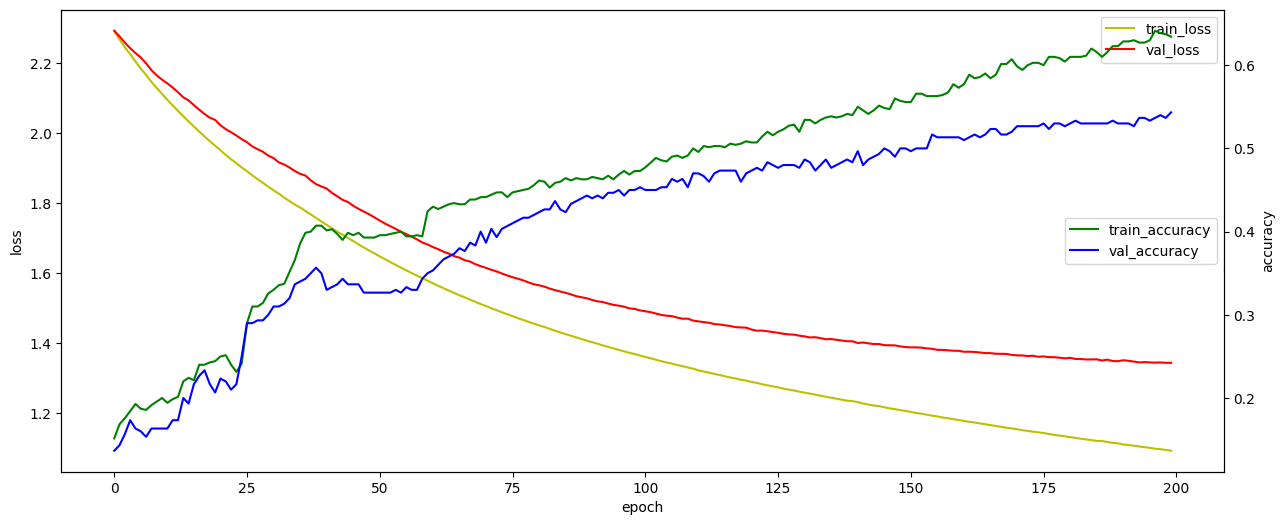

In [13]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
#acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')


acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

In [14]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X,test_Y,batch_size=100,verbose=0)
print('loss:',loss_metrics[0])
print('accuracy',loss_metrics[1])

loss: 5.157050609588623
accuracy 0.10109999775886536


# 위모델(DNN)의 accuracy늘리기
- 데이터 확보
- 모델수정(레이어 추가,units수 증가)
- 과적합 방지(validation data추가, 활성화함수를 relu계열, tahn,Dropout추가, 배치정규화,L2정규화(규제)...)
- epoch 조정
- optimizer 변경

In [25]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data() # 6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

train_X = X_train.reshape(50000,28*28).astype('float32')/255.0
val_X = X_val.reshape(10000,784).astype('float32')/255.0
test_X = X_val.reshape(10000,-1).astype('float32')/255.0

train_Y = to_categorical(y_train,10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)

# Train 5만 ->임의로 700개,val 1만 -> 임의로 300개 추출해서 학습
#idx=random.sample(range(50000),700)
# train_idx=np.random.choice(50000,700) # 0~50000미만의 700개의 수 비복원추출
# val_idx  = np.random.choice(10000,300)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X = val_X[val_idx]
# val_Y = val_Y[val_idx]

print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생섯(784-> 1024-> 512-> 128-> 10)
model = Sequential(name='sequential')
model.add(Input(shape=784,))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01))# 음수결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=128,activation='relu') )  
model.add(BatchNormalization())
model.add(Dropout(0.1))


model.add(Dense(units=10,activation='softmax'))
model.summary()
# 타겟변수를 원핫 인코딩 안했다면  sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
              optimizer = 'adam',
              metrics=['accuracy'])# 평가지표

hist = model.fit(train_X,train_Y,#학습셋
                validation_data=(val_X,val_Y),#검증셋
                batch_size=1000,
                epochs=30
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dropout_2 (Dropout)         (None, 2)                 0         
                                                                 
 dense_17 (Dense)            (None, 512)               1536      
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout_3 (Dropout)         (None, 512)       

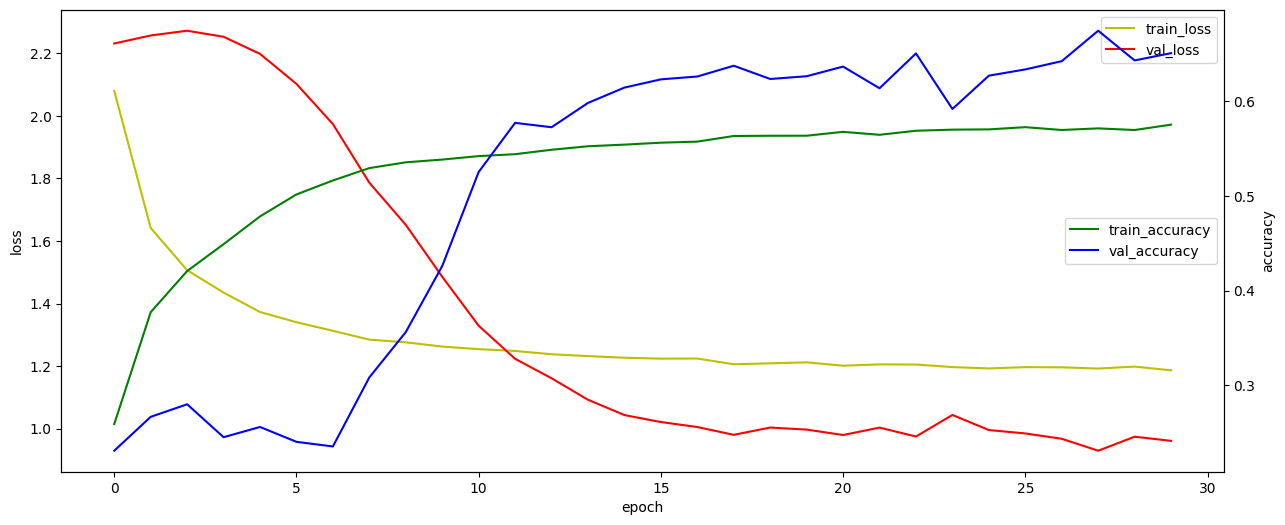

In [26]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
#acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')


acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

In [27]:
# 교차표
y_test
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1)==y_test)

True

In [28]:
y_hat = model.predict(test_X).argmax(axis=1) #예측값
y_hat = np.argmax(model.predict(test_X),axis=1)
y_hat

313/313 [==============================] - 1s 2ms/step


array([5, 8, 6, ..., 9, 6, 1], dtype=int64)